In [1]:
import astropy.units as u
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import pandas as pd
from snewpy.models.ccsn import Nakazato_2013, Bollig_2016
from snewpy.neutrino import Flavor, MassHierarchy
from snewpy.flavor_transformation import NoTransformation, AdiabaticMSW
import uproot

/home/iakovos-qpix/Programs/Library/MarleyTest/output/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
# ---------------------------
# File paths (update these to your actual file names)
# ---------------------------
file_paths = [
    #"/home/iakovos-qpix/Programs/Library/MarleyTest/output/Bollig_1000_events.root",
    #"/home/iakovos-qpix/Programs/Library/MarleyTest/output/Bollig_1000_NH_events.root",
   #"/home/iakovos-qpix/Programs/Library/MarleyTest/output/Bollig_1000_IH_events.root",
   "/home/iakovos-qpix/Programs/Library/MarleyTest/output/Nakazato_1000_events.root",
    "/home/iakovos-qpix/Programs/Library/MarleyTest/output/Nakazato_1000_NH_events.root",
   "/home/iakovos-qpix/Programs/Library/MarleyTest/output/Nakazato_1000_IH_events.root",

]

# Labels for legend
labels = [
    #"No Oscillations - Bollig Model",
    #"Normal Hierarchy - Bollig Model",
    #"Inverted Hierarchy - Bollig Model",
    "No Oscillations - Nakazato Model",
    "Normal Hierarchy - Nakazato Model",
    "Inverted Hierarchy - Nakazato Model",
]

# Colors for each dataset
colors = ["blue", "green", "red", "cyan", "magenta", "orange"]

# ---------------------------
# Loop over files and process
# ---------------------------
plt.figure(figsize=(10, 6))

# ---------------------------
# Loop over files and process
# ---------------------------
for path, label, color in zip(file_paths, labels, colors):
    print(f"Processing {label}...")
    file = uproot.open(path)
    tree = file["G4_Photons"]

    # 1. --- Load and Flatten Data ---
    # We use np.hstack because these branches are jagged (one entry per event)
    hx = np.hstack(tree["photon_hit_x"].array(library="np"))
    hy = np.hstack(tree["photon_hit_y"].array(library="np"))
    hz = np.hstack(tree["photon_hit_z"].array(library="np"))
    ht = np.hstack(tree["photon_hit_t"].array(library="np"))

    #print (hx)

    # 2. --- Apply Boundary Masking ---
    # X: 2 < x < 228 | Y: 5 < y < 595 | Z: 3 < z < 338
    mask = (hx > 2) & (hx < 228) & \
           (hy > 5) & (hy < 595)


    mask1 = (hx > 2) & (hx < 228) & \
            (hz > 3) & (hz < 338)
    
    
    clean_x = hx[mask]
    clean_y = hy[mask]
    clean_t = ht[mask] / 1e9  # Convert ns to s

    # 3. --- Plot 1: XY Heatmap (Spatial) ---
    plt.figure(figsize=(10, 7))
    plt.hist2d(clean_x, clean_y, bins=100, cmap='magma', cmin=1)
    plt.colorbar(label='Photon Intensity (Log Scale)')
    plt.xlabel("X Position [cm]")
    plt.ylabel("Y Position [cm]")
    plt.title(f"XY 2D Hit Map")
    plt.grid(alpha=0.2)
    plt.show()

    # 4. --- Plot 2: Photon Arrival Time (Temporal) ---
    plt.figure(figsize=(10, 5))
    # Filter time for unphysical values
    t_mask = (clean_t > 0) & (clean_t < 0.5) 
    
    plt.hist(
        clean_t[t_mask],
        bins=1000,
        color=color,
        alpha=0.7,
        label=label
    )
    plt.xlabel("Photon Arrival Time [s]")
    plt.ylabel("Photon Count")
    plt.title(f"Photon Timing Distribution: {label}")
    plt.xlim(0, 0.5)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()


188627396 photons in No Oscillations - Bollig Model
238675520 photons in Normal Hierarchy - Bollig Model
229913559 photons in Inverted Hierarchy - Bollig Model


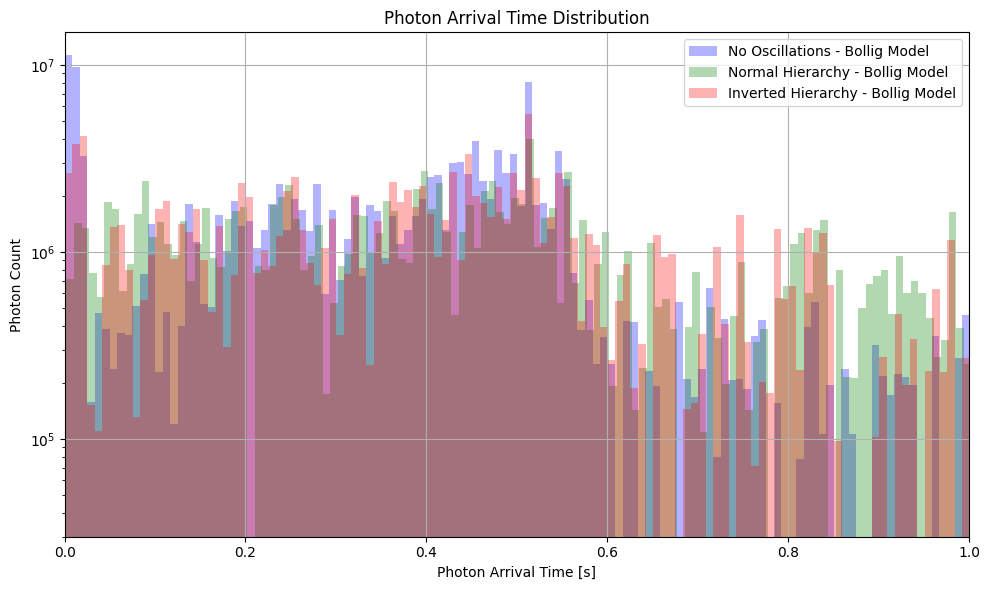

In [16]:

# ---------------------------
# File paths (update these to your actual file names)
# ---------------------------
file_paths = [
    "/home/iakovos-qpix/Programs/Library/MarleyTest/output/Bollig_1000_events.root",
    "/home/iakovos-qpix/Programs/Library/MarleyTest/output/Bollig_1000_NH_events.root",
   "/home/iakovos-qpix/Programs/Library/MarleyTest/output/Bollig_1000_IH_events.root",
   #"/home/iakovos-qpix/Programs/Library/MarleyTest/output/Nakazato_1000_events.root",
  #  "/home/iakovos-qpix/Programs/Library/MarleyTest/output/Nakazato_1000_NH_events.root",
   #"/home/iakovos-qpix/Programs/Library/MarleyTest/output/Nakazato_1000_IH_events.root",

]

# Labels for legend
labels = [
    "No Oscillations - Bollig Model",
    "Normal Hierarchy - Bollig Model",
    "Inverted Hierarchy - Bollig Model",
    #"No Oscillations - Nakazato Model",
    #"Normal Hierarchy - Nakazato Model",
    #"Inverted Hierarchy - Nakazato Model",
]

# Colors for each dataset
colors = ["blue", "green", "red", "cyan", "magenta", "orange"]

# ---------------------------
# Loop over files and process
# ---------------------------
plt.figure(figsize=(10, 6))

for path, label, color in zip(file_paths, labels, colors):
    # Open ROOT file
    file = uproot.open(path)
    tree = file["G4_Photons"]

    # Load photon times
    photon_times = tree["photon_hit_t"].array(library="np")  # jagged list of events

    # Flatten
    all_photon_times = np.hstack(photon_times)

    # Filter unphysical values
    mask = (all_photon_times > 0) & (all_photon_times < 1e10)
    clean_photon_times = all_photon_times[mask]

    # Convert ns → s
    clean_photon_times_s = clean_photon_times / 1e9
    
    print(len(clean_photon_times_s), "photons in", label)

    # Plot histogram
    plt.hist(
    clean_photon_times_s,
    bins=1000,
    color=color,
    alpha=0.3,  # transparency for overlap
    label=label
    )

# ---------------------------
# Final plot formatting
# ---------------------------
plt.xlabel("Photon Arrival Time [s]")
plt.ylabel("Photon Count")
#plt.xscale("log")  # Uncomment if you want log x-axis
plt.yscale("log")
plt.title("Photon Arrival Time Distribution")
plt.xlim(0, 1)  # Adjust as needed
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


Generating graph for No Oscillations...


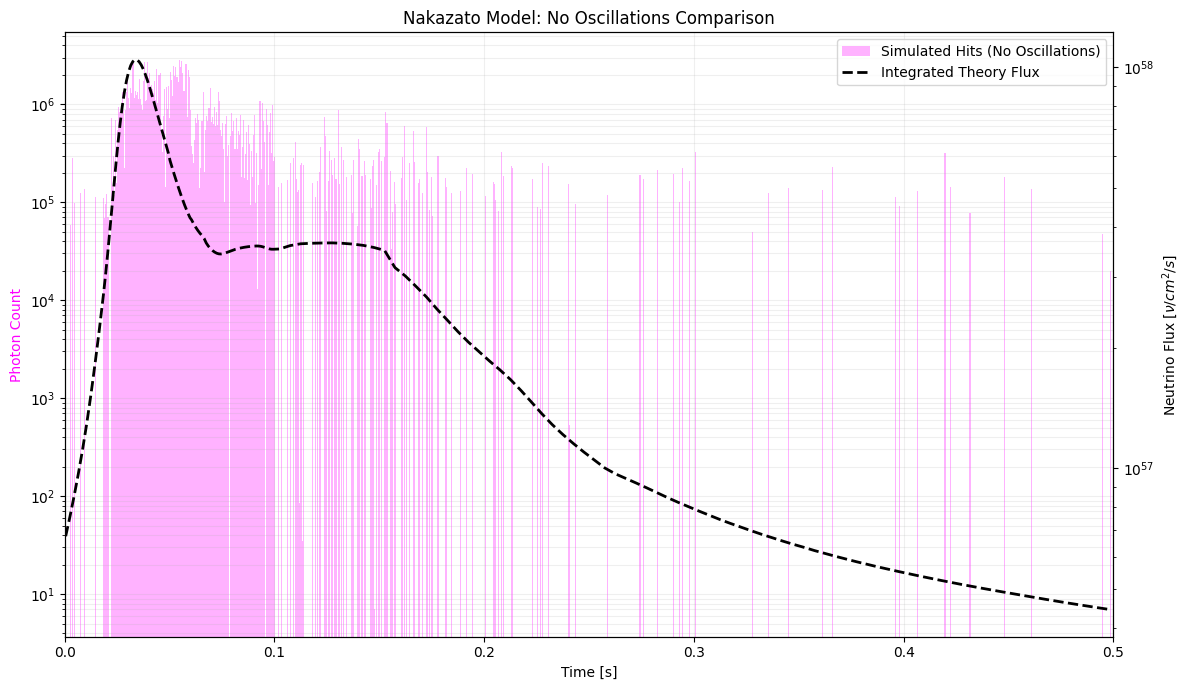

Generating graph for Normal Hierarchy...


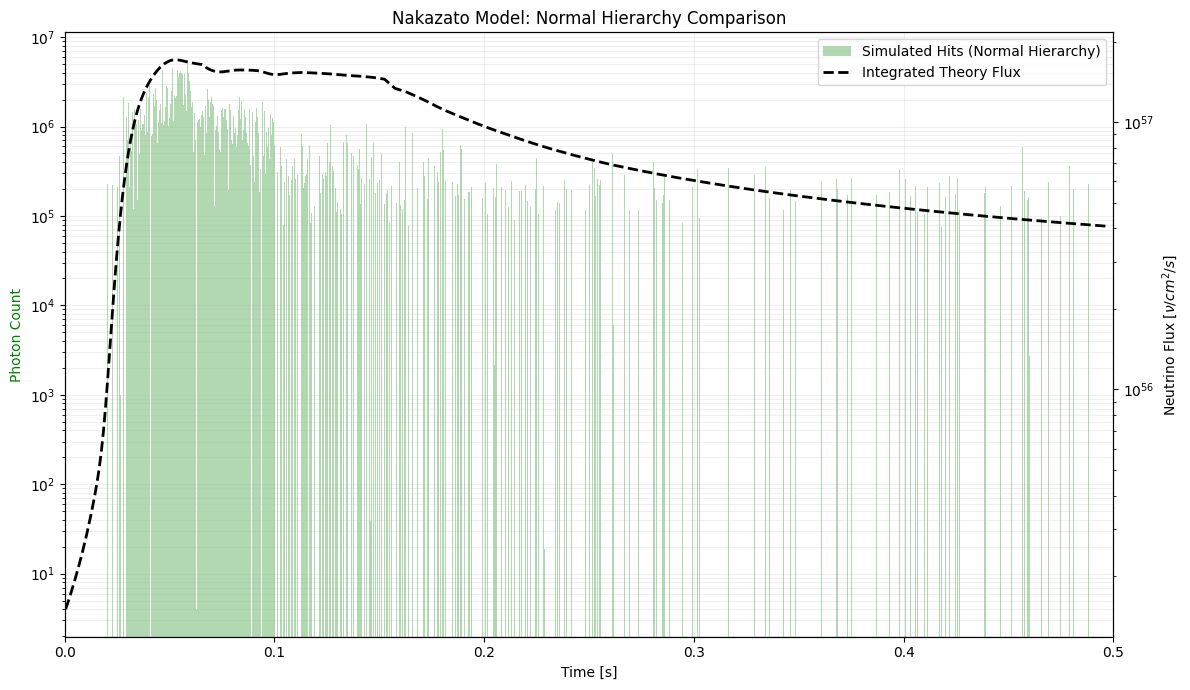

Generating graph for Inverted Hierarchy...


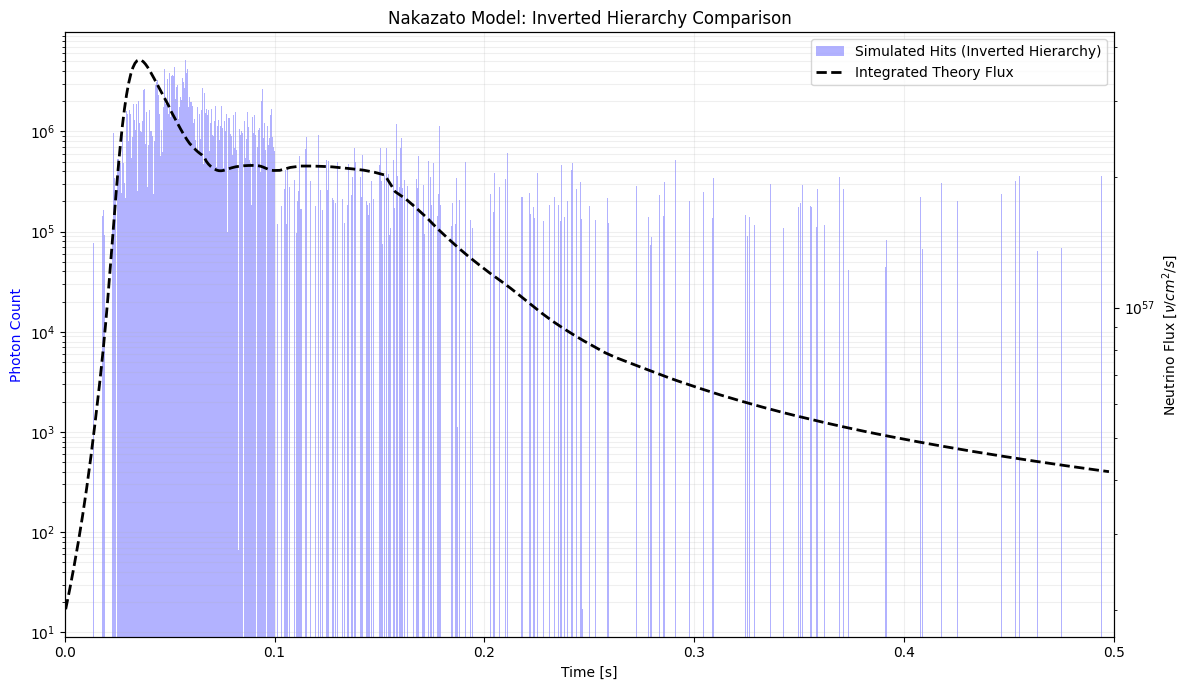

In [1]:
import uproot
import numpy as np
import matplotlib.pyplot as plt

# --- Configuration Mapping ---
scenarios = {
    "No_Osc": {
        "sim_path": "/home/iakovos-qpix/Programs/Library/MarleyTest/output/Nakazato_1000_events.root",
        "flux_key": "h2d_Nakazato_No_Oscillations",
        "color": "magenta",
        "label": "No Oscillations"
    },
    "NH": {
        "sim_path": "/home/iakovos-qpix/Programs/Library/MarleyTest/output/Nakazato_1000_NH_events.root",
        "flux_key": "h2d_Nakazato_Normal_Hierarchy",
        "color": "green",
        "label": "Normal Hierarchy"
    },
    "IH": {
        "sim_path": "/home/iakovos-qpix/Programs/Library/MarleyTest/output/Nakazato_1000_IH_events.root",
        "flux_key": "h2d_Nakazato_Inverted_Hierarchy",
        "color": "blue",
        "label": "Inverted Hierarchy"
    }
}

path_flux = "/home/iakovos-qpix/Programs/Library/MarleyTest/macros/supernova_data_Nakazato.root"
flux_file = uproot.open(path_flux)

# Loop to generate separate graphs
for key, config in scenarios.items():
    print(f"Generating graph for {config['label']}...")
    
    # Create a new figure for each hierarchy
    fig, ax1 = plt.subplots(figsize=(12, 7))
    ax2 = ax1.twinx()

    # 1. --- Simulation Data (Left Axis) ---
    try:
        with uproot.open(config['sim_path']) as sim_file:
            tree = sim_file["G4_Photons"]
            # hstack converts jagged arrays to a flat numpy array
            all_photon_times = np.hstack(tree["photon_hit_t"].array(library="np"))
            
            # Mask: t > 0 and within 0.5s (5e8 ns)
            mask_sim = (all_photon_times > 0) & (all_photon_times < 5e8)
            clean_photon_times_s = all_photon_times[mask_sim] / 1e9
            
            # Histogramming simulation hits
            ax1.hist(clean_photon_times_s, bins=1000, color=config['color'], 
                     alpha=0.3, label=f"Simulated Hits ({config['label']})")
            
            # Explicit cleanup to prevent memory bloating
            del all_photon_times
            del clean_photon_times_s
    except Exception as e:
        print(f"Error loading simulation file for {key}: {e}")
        plt.close(fig)
        continue

    # 2. --- Integrated Theory Flux (Right Axis) ---
    h2d = flux_file[config['flux_key']]
    spec_nue = h2d.values()     # (Time, Energy)
    t_centers = h2d.axis(0).centers()
    E_centers = h2d.axis(1).centers()

    # Integrate over Energy (Axis 1) to get Flux vs. Time
    flux_vs_time = np.trapezoid(spec_nue, x=E_centers, axis=1)

    # Log-safety mask
    mask_theory = (t_centers > 0) & (t_centers < 0.5) & (flux_vs_time > 0)

    ax2.plot(t_centers[mask_theory], flux_vs_time[mask_theory], 
             color="black", linestyle="--", linewidth=2, label="Integrated Theory Flux")

    # --- Formatting for this specific graph ---
    ax1.set_xlabel("Time [s]")
    ax1.set_ylabel("Photon Count", color=config['color'])
    ax2.set_ylabel("Neutrino Flux [$\\nu / cm^2 / s$]", color="black")
    
    ax1.set_yscale("log")
    ax2.set_yscale("log")
    ax1.set_xlim(0, 0.5)
    
    ax1.set_title(f"Nakazato Model: {config['label']} Comparison")
    ax1.grid(True, which="both", alpha=0.2)
    
    # Combined Legend
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right")

    plt.tight_layout()
    plt.show() # Or plt.savefig(f"Backtest_{key}.png") to save them automatically

Analyzing burst structure for No_Osc...


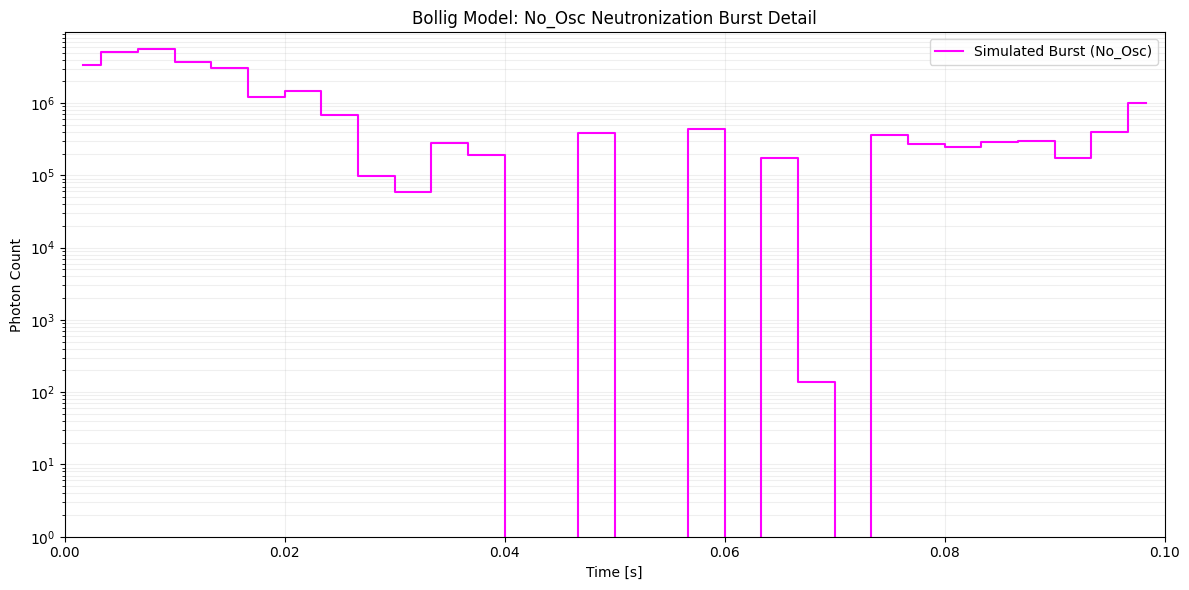

Analyzing burst structure for NH...


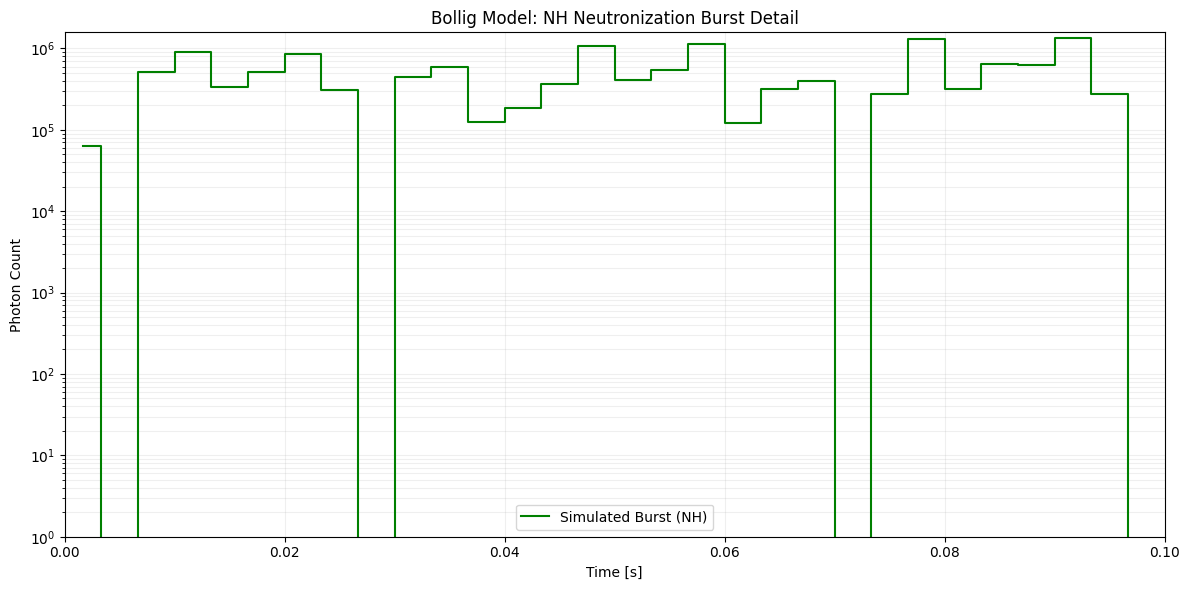

Analyzing burst structure for IH...


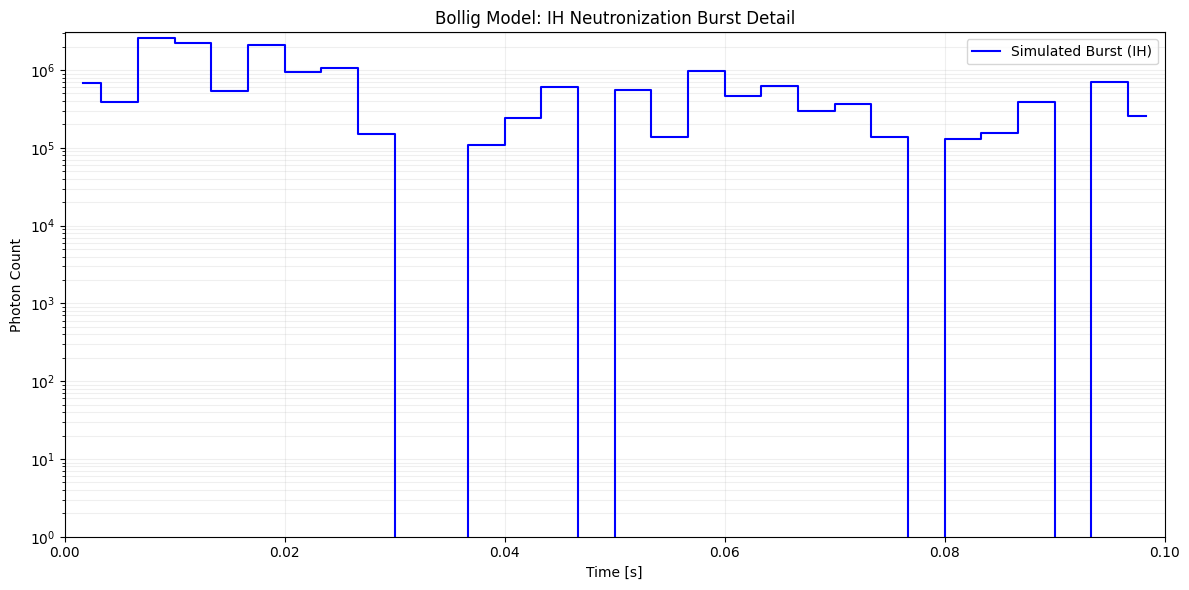

In [25]:
import uproot
import numpy as np
import matplotlib.pyplot as plt

# --- Focus Settings ---
t_start, t_end = 0.0, 0.1  # Zoom into the first 100ms
num_bins = 30            # This gives 50 microsecond resolution

# Scenarios as defined in your prompt
scenarios = {
    "No_Osc": {"sim_path": "Bollig_1000_events.root", "flux_key": "h2d_Bollig_No_Oscillations", "color": "magenta"},
    "NH": {"sim_path": "Bollig_1000_NH_events.root", "flux_key": "h2d_Bollig_Normal_Hierarchy", "color": "green"},
    "IH": {"sim_path": "Bollig_1000_IH_events.root", "flux_key": "h2d_Bollig_Inverted_Hierarchy", "color": "blue"}
}

for key, config in scenarios.items():
    print(f"Analyzing burst structure for {key}...")
    
    # Initialize high-res binning arrays
    global_counts = np.zeros(num_bins)
    bin_edges = np.linspace(t_start, t_end, num_bins + 1)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

    # 1. --- Chunked Processing (Memory Safe) ---
    with uproot.open(config['sim_path']) as sim_file:
        tree = sim_file["G4_Photons"]
        # Process in chunks to reach high resolution without crashing
        for chunk in tree.iterate(["photon_hit_t"], step_size="100MB", library="np"):
            times_s = np.concatenate(chunk["photon_hit_t"]) / 1e9
            
            # Add to our counts
            counts, _ = np.histogram(times_s, bins=bin_edges)
            global_counts += counts

    # 2. --- Plotting with plt.step ---
    fig, ax1 = plt.subplots(figsize=(12, 6))
    
    # plt.step provides the 'outline' of the histogram without the memory overhead of bars
    ax1.step(bin_centers, global_counts, where='mid', color=config['color'], 
             linewidth=1.5, label=f"Simulated Burst ({key})")
    
    # Log scale is still useful to see the rise from zero
    ax1.set_yscale("log")
    ax1.set_xlim(t_start, t_end)
    ax1.set_ylim(bottom=1) # Prevent log(0) issues
    
    ax1.set_xlabel("Time [s]")
    ax1.set_ylabel("Photon Count")
    ax1.set_title(f"Bollig Model: {key} Neutronization Burst Detail")
    ax1.grid(True, which="both", alpha=0.2)
    ax1.legend()

    plt.tight_layout()
    plt.show()

The cell bellow is responsible for graphing single root file. 

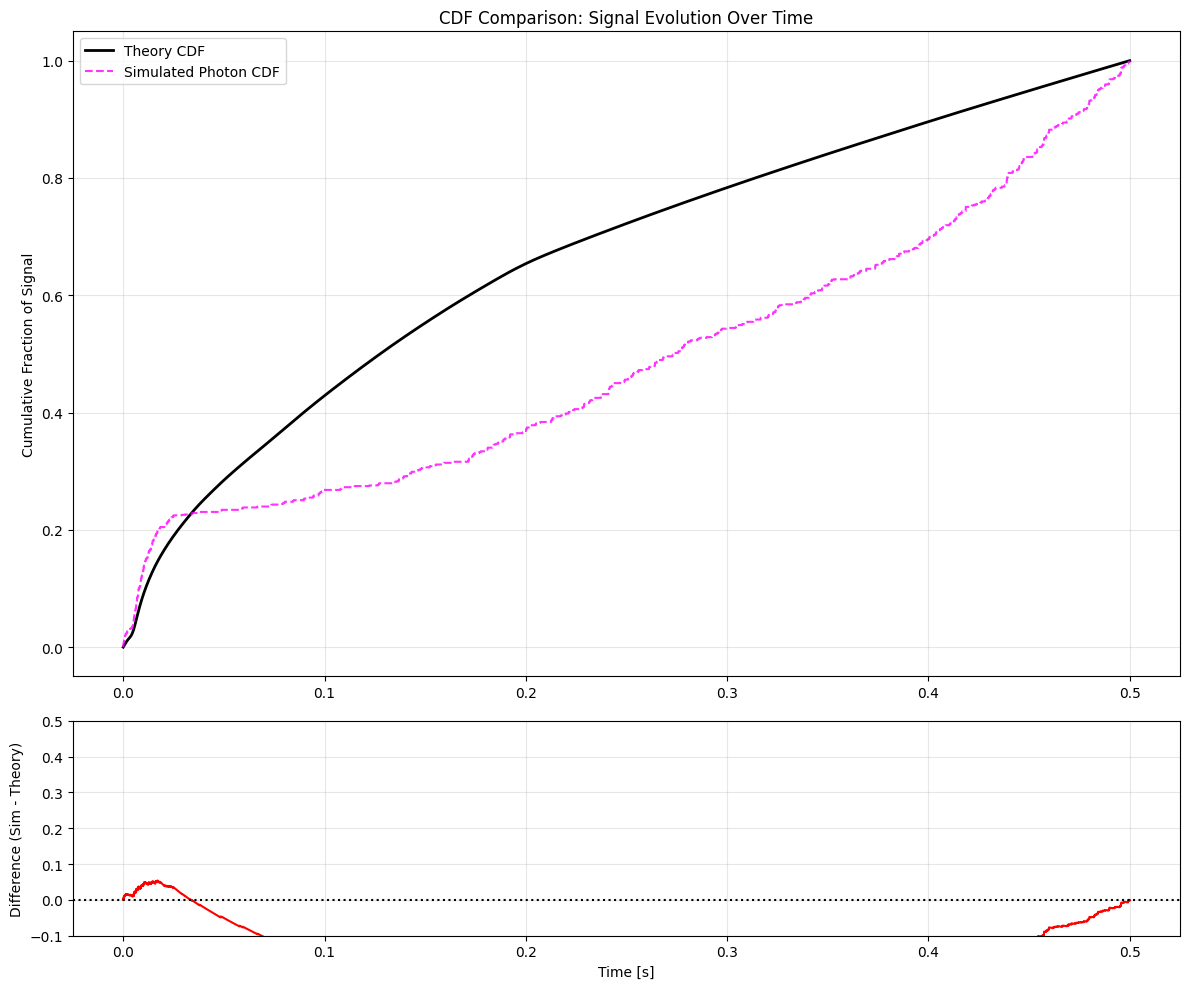

In [10]:
import uproot
import numpy as np
import matplotlib.pyplot as plt

# --- Configuration ---
# Use the same chunked approach to prevent crashes
path_sim = "/home/iakovos-qpix/Programs/Library/MarleyTest/output/Bollig_1000_events.root"
path_flux = "/home/iakovos-qpix/Programs/Library/MarleyTest/macros/supernova_data_Bollig.root"
t_window = (0, 0.5)
num_bins = 500000  # 10us resolution is plenty for CDF

# --- 1. Process Simulation CDF ---
global_counts = np.zeros(num_bins)
bin_edges = np.linspace(t_window[0], t_window[1], num_bins + 1)

with uproot.open(path_sim) as file:
    tree = file["G4_Photons"]
    for chunk in tree.iterate(["photon_hit_t"], step_size="100MB", library="np"):
        times_s = np.concatenate(chunk["photon_hit_t"]) / 1e9
        counts, _ = np.histogram(times_s, bins=bin_edges)
        global_counts += counts

# Calculate CDF for Simulation
cdf_sim = np.cumsum(global_counts)
cdf_sim = cdf_sim / cdf_sim[-1]  # Normalize to 1.0

# --- 2. Process Theory CDF ---
flux_file = uproot.open(path_flux)
h2d = flux_file["h2d_Bollig_No_Oscillations"]
spec_nue = h2d.values()
t_centers = h2d.axis(0).centers()
E_centers = h2d.axis(1).centers()

# Energy-integrated flux vs time
flux_vs_time = np.trapezoid(spec_nue, x=E_centers, axis=1)

# Interpolate theory flux to match our simulation binning for direct comparison
# (Theory is usually coarser than simulation)
interp_flux = np.interp(bin_edges[:-1], t_centers, flux_vs_time)
cdf_theory = np.cumsum(interp_flux)
cdf_theory = cdf_theory / cdf_theory[-1]

# --- 3. Robust Comparison Plot ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), gridspec_kw={'height_ratios': [3, 1]})

bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

# Top Plot: The CDFs
ax1.plot(bin_centers, cdf_theory, color='black', label="Theory CDF", linewidth=2)
ax1.plot(bin_centers, cdf_sim, color='magenta', linestyle='--', label="Simulated Photon CDF", alpha=0.8)

ax1.set_ylabel("Cumulative Fraction of Signal")
ax1.set_title("CDF Comparison: Signal Evolution Over Time")
ax1.grid(True, alpha=0.3)
ax1.legend()

# Bottom Plot: The Residual (The "Difference")
# This is where you see the detector effect clearly
residual = cdf_sim - cdf_theory
ax2.plot(bin_centers, residual, color='red')
ax2.axhline(0, color='black', linestyle=':')
ax2.set_ylabel("Difference (Sim - Theory)")
ax2.set_xlabel("Time [s]")
ax2.set_ylim(-0.1, 0.5) # Zoom in on the variance
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:

# Assume clean_photon_times_s is your photon arrival data in seconds
bin_width = 1e-3
bins = np.arange(0, clean_photon_times_s.max(), bin_width)
plt.hist(clean_photon_times_s, bins=bins, label="No Oscillations")

plt.xscale("log")
plt.yscale("log")
plt.xlabel("Time [s]")
plt.ylabel("Photon Count")
plt.legend()
plt.show()
